# Lorenz 63 

Dynamics: with $\sigma=10, \rho=28, \beta=\frac{8}{3}$, 
$$
\begin{align}
\frac{dx}{dt} &= \sigma (y-x) \\
\frac{dy}{dt} &= x (\rho - z) - y \\
\frac{dz}{dt} &= xy - \beta z
\end{align}
$$


References: 
- https://cdanfort.w3.uvm.edu/research/lorenz-1963.pdf
- https://cmp.phys.ufl.edu/PHZ4710/files/unit5/Lorenz-system.html

In [1]:
import os, glob
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from dataprocessing_utils.lorenz import Lorenz, LorenzDataset, LorenzTrajectory, REF_TRAJ_FILEPATHS

Trajectory = LorenzTrajectory
Dataset = LorenzDataset

In [20]:
def plot_xyz(dataset_or_trajs, axis_lims=None, linestyles=None, legend_labels=None, axis_labels=None, 
                     title=None, figsize=(6, 4), show_legend=False, save_path=None):

    if axis_lims is None:
        axis_lims = [(None, None)] * 3  # Default axis limits

    if linestyles is None:
        linestyles = ['-'] * len(dataset_or_trajs)  # Default linestyle for all plots
    elif isinstance(linestyles, str):
        linestyles = [linestyles] * len(dataset_or_trajs)

    if legend_labels is None:
        legend_labels = ['Trajectory {}'.format(i+1) for i in range(len(dataset_or_trajs))]  # Default labels for legends

    if axis_labels is None:
        axis_labels = ['$x$', '$y$', '$z$']  # Default axis labels

    fig = plt.figure(figsize=figsize, layout='constrained')
    ax = fig.subplots(1, 1, subplot_kw={'projection': '3d'})  # Use plt.subplots to manage multiple axes

    lines = []  # List to hold the line objects for the legend
    for traj, linestyle, legend_label in zip(dataset_or_trajs, linestyles, legend_labels):
        u = traj.states.u 
        x, y, z = u[:, 0], u[:, 1], u[:, 2]
        if legend_label == 'ref':
            line1, = ax.plot(x, y, z, linestyle, lw=1, color='k', alpha=0.3, label=legend_label)
        else:
            line1, = ax.plot(x, y, z, linestyle, lw=1, label=legend_label)
        lines.append(line1)  # Append the line object for the legend
        

    # Set labels and titles for each subplot
    if axis_lims is not None:
        ax.set_xlim(axis_lims[0])
        ax.set_ylim(axis_lims[1])
        ax.set_zlim(axis_lims[2])
    ax.set_xlabel(axis_labels[0])
    ax.set_ylabel(axis_labels[1])
    ax.set_zlabel(axis_labels[2])
    
    if title is not None:
        ax.set_title(title)

    if show_legend:
        # Place a single legend outside the right of the subplots
        fig.legend(lines, legend_labels, loc='outside center right', borderaxespad=0.1)
        # plt.subplots_adjust(right=0.85)  # Adjust the right boundary of the subplots to make room for the legend

    # plt.tight_layout()

    if save_path:
        plt.savefig(save_path, format='png', dpi=300)  # Save the figure to the specified path
        print(f"Figure saved as '{save_path}'")
    else:
        plt.show()

    return


def plot_xyz_projected(dataset_or_trajs, axis_lims=None, linestyles=None, legend_labels=None, axis_labels=None, 
                     titles=None, figsize=(12, 4), show_legend=False, save_path=None):
    
    if axis_lims is None:
        # axis_lims = [[(-5., 5.), (-5., 5.)]] * 3  # Default axis limits for all subplots
        axis_lims = [[None, None]] * 3  # Default axis limits for all subplots

    if linestyles is None:
        linestyles = ['-'] * len(dataset_or_trajs)  # Default linestyle for all plots
    
    if legend_labels is None:
        legend_labels = ['Trajectory {}'.format(i+1) for i in range(len(dataset_or_trajs))]  # Default labels for legends

    if axis_labels is None:
        axis_labels = [('$x$', '$y$'), 
                       ('$x$', '$z$'),
                       ('$y$', '$z$')]  # Default axis labels

    if titles is None:
        titles = ['xy-plane', 'xz-plane', 'yz-plane']  # Default titles for subplots

    fig = plt.figure(figsize=figsize, layout='constrained')
    axes = fig.subplots(1, 3)  # Use plt.subplots to manage multiple axes

    lines = []  # List to hold the line objects for the legend
    for traj, linestyle, legend_label in zip(dataset_or_trajs, linestyles, legend_labels):
        u = traj.states.u 
        x, y, z = u[:, 0], u[:, 1], u[:, 2]
        if legend_label == 'ref':
            line1, = axes[0].plot(x, y, linestyle, lw=1, color='k', alpha=0.3, label=legend_label)
            axes[1].plot(x, z, linestyle, lw=1, color='k', alpha=0.3)
            axes[2].plot(y, z, linestyle, lw=1, color='k', alpha=0.3)
        else:
            line1, = axes[0].plot(x, y, linestyle, lw=1, label=legend_label)
            axes[1].plot(x, z, linestyle, lw=1)
            axes[2].plot(y, z, linestyle, lw=1)
        lines.append(line1)  # Append the line object for the legend
        

    # Set labels and titles for each subplot
    for i, ax in enumerate(axes):
        if axis_lims is not None:
            ax.set_xlim(axis_lims[i][0])
            ax.set_ylim(axis_lims[i][1])
        ax.set_xlabel(axis_labels[i][0])
        ax.set_ylabel(axis_labels[i][1])
        ax.set_title(titles[i])

    if show_legend:
        # Place a single legend outside the right of the subplots
        fig.legend(lines, legend_labels, loc='outside center right', borderaxespad=0.1)
        # plt.subplots_adjust(right=0.85)  # Adjust the right boundary of the subplots to make room for the legend

    # plt.tight_layout()

    if save_path:
        plt.savefig(save_path, format='png', dpi=300)  # Save the figure to the specified path
        print(f"Figure saved as '{save_path}'")
    else:
        plt.show()

    return


def plot_history(dataset_or_trajs, func_dict, linestyles=None, alpha=1., legend_labels=None, xlabel="t", ylabels=None, ylims=None, 
               figsize=None, show_legend=True, save_path=None):
    
    if linestyles is None:
        linestyles = ['-'] * len(dataset_or_trajs)  # Default linestyle for all plots
    
    if legend_labels is None:
        legend_labels = ['Trajectory {}'.format(i+1) for i in range(len(dataset_or_trajs))]  # Default labels for legends
    
    if ylabels is None:
        ylabels = list(func_dict.keys())  # Default y axis labels

    if ylims is None:
        ylims = [(None, None)] * len(func_dict.keys())
    
    if figsize is None:
        figsize = (8, 1.5 * len(func_dict))

    fig, axes = plt.subplots(len(func_dict), 1, figsize=figsize, layout='constrained')  # Use plt.subplots to manage multiple axes

    lines = []  # List to hold the line objects for the legend
    for traj, linestyle, legend_label in zip(dataset_or_trajs, linestyles, legend_labels):
        xdata = traj.times if isinstance(traj, Trajectory) else np.arange(len(traj))
        for i, (key, func) in enumerate(func_dict.items()):
            if len(func_dict) > 1:
                if legend_label == 'ref':
                    line1, = axes[i].plot(xdata, func(traj.states.u), linestyle, lw=1, alpha=0.2, color='k', label=legend_label)
                else:
                    line1, = axes[i].plot(xdata, func(traj.states.u), linestyle, lw=1, alpha=alpha, label=legend_label)
            else:
                if legend_label == 'ref':
                    line1, = axes.plot(xdata, func(traj.states.u), linestyle, lw=1, alpha=0.2, color='k', label=legend_label)
                else:
                    line1, = axes.plot(xdata, func(traj.states.u), linestyle, lw=1, alpha=alpha, label=legend_label)
        lines.append(line1) # Append the line object for the legend

    # Set labels and titles for each subplot
    if len(func_dict) > 1:
        for i, ax in enumerate(axes):
            ax.set_ylim(ylims[i])
            ax.set_xlabel(xlabel)
            ax.set_ylabel(ylabels[i])
    else:
        axes.set_ylim(ylims[0])
        axes.set_xlabel(xlabel)
        axes.set_ylabel(ylabels[0])

    if show_legend:
        # Place a single legend outside the right of the subplots
        fig.legend(lines, legend_labels, loc='outside center right', borderaxespad=0.1)
        # plt.subplots_adjust(right=0.85)  # Adjust the right boundary of the subplots to make room for the legend

    # plt.tight_layout()

    if save_path:
        plt.savefig(save_path, format='png', dpi=300)  # Save the figure to the specified path
        print(f"Figure saved as '{save_path}'")
    else:
        plt.show()

    return 


def plot_errors(trajs, ref_trajs, linestyles=None, legend_labels=None, titles=None, error_names=None, 
                ylims=None, ylabels=None, figsize=None, log_yscale=True, show_legend=False, save_path=None):
    
    if isinstance(ref_trajs, Trajectory):
        ref_trajs = [ref_trajs] * len(trajs)
    elif isinstance(ref_trajs, list):
        assert len(trajs) == len(ref_trajs), "Number of trajs and ref_trajs must be the same"
    else:
        raise ValueError("ref_trajs must be a Trajectory or a list of Trajectories")

    if linestyles is None:
        linestyles = ['-'] * len(trajs)  # Default linestyle for all plots
    
    if legend_labels is None:
        legend_labels = ['Trajectory {}'.format(i+1) for i in range(len(trajs))]  # Default labels for legends
    
    if error_names is None:
        error_names = ["abs_traj_err", "abs_H_err"]
    
    if ylims is None:
        ylims = [(1e-5, 1e1)] * len(error_names)  # Default ylims for subplots
    
    if ylabels is None:
        ylabels = error_names  # Default y axis labels
    
    if figsize is None:
        figsize = (8, 1.5 * len(error_names))

    fig, axes = plt.subplots(len(error_names), 1, figsize=figsize, layout='constrained')  # Use plt.subplots to manage multiple axes

    lines = []  # List to hold the line objects for the legend
    for traj, ref_traj, linestyle, legend_label in zip(trajs, ref_trajs, linestyles, legend_labels):
        tt, errors = traj.compare(ref_traj)
        for i, error_name in enumerate(error_names):
            if len(error_names) > 1:
                line1, = axes[i].plot(tt, errors[error_name], linestyle, lw=1, label=legend_label)
            else:
                line1, = axes.plot(tt, errors[error_name], linestyle, lw=1, label=legend_label)
        lines.append(line1)
        # line1, = axes[0].plot(tt, errors[error_names[0]], linestyle, lw=1, label=legend_label)
        # axes[1].plot(tt, errors[error_names[1]], linestyle, lw=1)
        # lines.append(line1)  # Append the line object for the legend

    # Set labels and titles for each subplot
    for i, ax in enumerate(axes.flatten()):
        ax.set_ylim(ylims[i])
        ax.set_xlabel('$t$')
        ax.set_ylabel(ylabels[i])
        if log_yscale:
            ax.set_yscale('log')

    if show_legend:
        # Place a single legend outside the right of the subplots
        fig.legend(lines, legend_labels, loc='outside center right', borderaxespad=0.1)
        # plt.subplots_adjust(right=0.85)  # Adjust the right boundary of the subplots to make room for the legend

    # plt.tight_layout()

    if save_path:
        plt.savefig(save_path, format='png', dpi=300)  # Save the figure to the specified path
        print(f"Figure saved as '{save_path}'")
    else:
        plt.show()

    return


## Usage example

In [4]:
traj_indices = [1]
traj_labels = ['Trajectory {}'.format(i) for i in traj_indices]
ref_trajs = [
    Trajectory.load_from_file(REF_TRAJ_FILEPATHS[i]["filepath"], dt=REF_TRAJ_FILEPATHS[i]["dt"]) 
    for i in traj_indices
]

ref_trajs

[LorenzTrajectory(t_range=[0.0, 100.0], dt=0.001, u0=[1. 0. 0.], states=States(problem=Lorenz(sigma=10.0, rho=28.0, beta=2.6666666666666665), shape=(100001, 3)))]

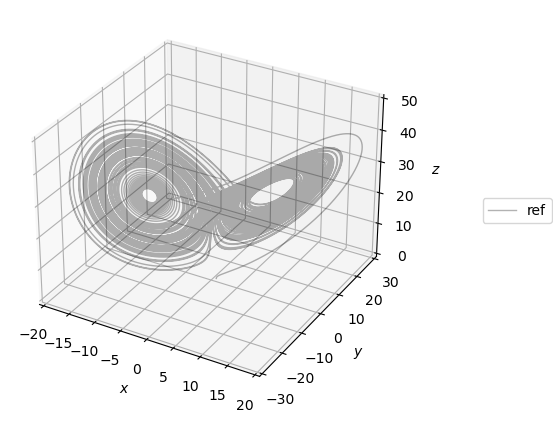

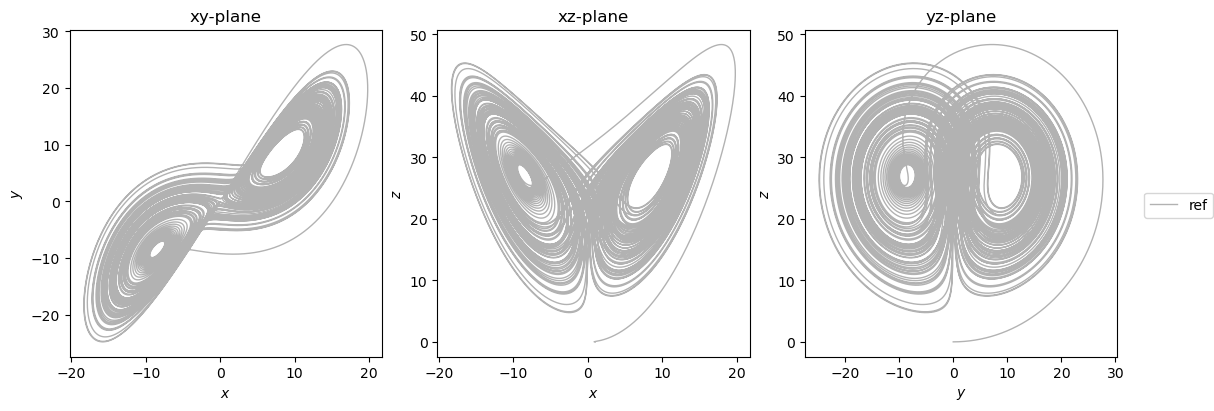

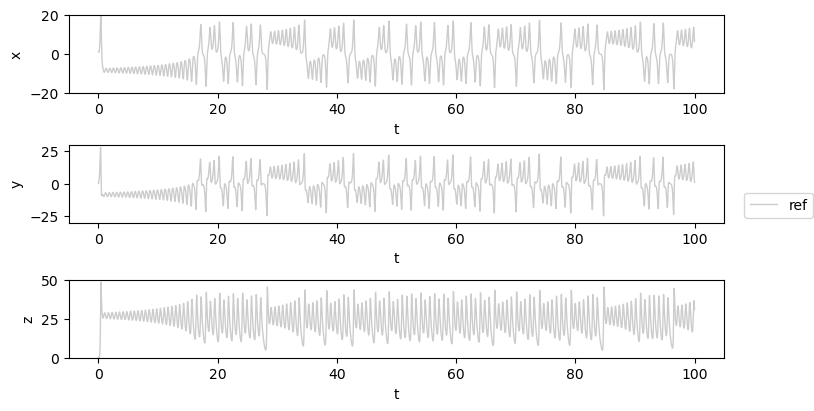

In [13]:
plot_xyz(
    ref_trajs, 
    axis_lims=[(-20, 20), (-30, 30), (0, 50)], 
    linestyles='-', 
    legend_labels=['ref'], 
    figsize=(6, 4), 
    show_legend=True
)
plot_xyz_projected(
    ref_trajs, 
    # axis_lims=[(-20, 20), (0, 50), (-30, 30)], 
    linestyles='-', 
    legend_labels=['ref'], 
    figsize=(12, 4), 
    show_legend=True
)

plot_history(
    ref_trajs, 
    func_dict={'x': lambda u: u[:, 0], 'y': lambda u: u[:, 1], 'z': lambda u: u[:, 2]}, 
    linestyles='-', 
    legend_labels=['ref'], 
    xlabel='t', 
    ylabels=['x', 'y', 'z'], 
    ylims=[(-20, 20), (-30, 30), (0, 50)], 
    figsize=(8, 4), 
    show_legend=True
)

## Load model checkpoints

In [14]:
import sys
sys.path.append("../deep_learning/src")

import re 
import torch

from utils.checkpoint_utils import load_model_from_ckpt
from modules.variable_timestep import T0CenteredSolutionMap
from modules.collocation_handler import CollocationPointsGenerator
from datamodules.datasets import get_sequence_data

In [15]:
def dPhidt(model):
    return lambda u, t: torch.func.vmap(torch.func.jacrev(model, argnums=1))(u, t).squeeze(-1)  # (bs, 2*dof)

def dPhidu(model):
    return lambda u, t: torch.func.vmap(torch.func.jacrev(model, argnums=0))(u, t)  # (bs, 2*dof, 2*dof)

def det_dPhidu(model):
    return lambda u, t: torch.det(dPhidu(model)(u, t))  # (bs,)

def get_epoch_from_ckpt(ckpt_path):
    # Search for pattern 'epoch' followed by digits
    match = re.search(r'epoch(\d+)', ckpt_path)
    if match:
        return int(match.group(1))
    return None

def load_checkpoint_history(ckpt_dir, model_name):
    ckpt_paths = glob.glob(ckpt_dir + "/*epoch*.ckpt")
    ckpt_paths = sorted(ckpt_paths, key=lambda ckpt: get_epoch_from_ckpt(ckpt))

    model_ckpts = {}
    for path in ckpt_paths:
        model_ckpts[f"epoch{get_epoch_from_ckpt(path)}"] = {
            "model_name": model_name,
            "ckpt_path": path
        }
    return model_ckpts

def find_latest_ckpt(ckpt_dir):
    latest_ckpt = glob.glob(f"{ckpt_dir}/latest*.ckpt")
    if latest_ckpt:
        return latest_ckpt[0]
    else:
        raise FileNotFoundError(f"No latest checkpoint found in {ckpt_dir}")
    
def get_batch(batch_size, data_dir, t_range=None, t=None):
    data_config = {
        "data_dir": data_dir,
        "sequence_len": 2, 
        "dtype": "float64",
        "downsample_factor": 1,
        "Dt_filter": t_range,
        "Dt": t
    }
    ds = get_sequence_data(data_config)
    return ds[:batch_size]

### Trajectories

In [18]:
def predict_sequence(model, t, reference_trajectory):
    traj = reference_trajectory.select_with_interval(t)

    u0 = torch.tensor(traj.states.u[0], dtype=model.dtype).to(model.device).unsqueeze(0)
    t = torch.tensor([t], dtype=model.dtype).to(model.device).unsqueeze(0)
    
    u = u0
    u_seq = [u0]
    for i in range(len(traj) - 1):
        u = model(u, t)
        u_seq.append(u)

    u_seq = torch.stack(u_seq, dim=0).squeeze(1).detach().cpu().numpy()
    pred_traj = Trajectory.from_u(traj.times, u_seq)
    return pred_traj

def predict_sequence2(model, t, reference_trajectory):
    traj = reference_trajectory.select_with_interval(t)

    u0 = torch.tensor(traj.states.u[0], dtype=model.dtype).to(model.device).unsqueeze(0).repeat(len(traj), 1)  # (len(traj), 12)
    t_seq = torch.tensor(traj.times, dtype=model.dtype).to(model.device).unsqueeze(-1) # (len(traj), 1)
    
    u_seq = model(u0, t_seq)
    u_seq = u_seq.detach().cpu().numpy()
    pred_traj = Trajectory.from_u(traj.times, u_seq)
    return pred_traj

def plot_numerical_residual_along_traj(models, legend_labels, trajs, component_idx=None):

    if isinstance(trajs, Trajectory):
        trajs = [trajs] * len(models)

    plt.figure(figsize=(5, 2))

    for model, label, traj in zip(models, legend_labels, trajs):
        u0 = torch.tensor(traj.states.u, dtype=model.dtype).to(model.device)  # (len(traj), 12)
        dt = traj.times[1]-traj.times[0]
        t = torch.tensor([dt], dtype=model.dtype).to(model.device).unsqueeze(0).repeat((len(u0), 1)) # (len(traj), 1)
        
        if model.loss_hparams.get("numerical_residual", None) is not None:
            vv_config = model.loss_hparams["numerical_residual"]["integrator"]
        else:
            vv_config = {"method": "ImplicitMidpoint", "stepsize": 0.01, "nsteps": 1}

        vv = model._instantiate_integrator(vv_config)
        print(vv)

        errors = model._calc_numerical_residual_error(u0, t, vv, reduction="none", use_mse=True) # (len(traj), 12)
        if component_idx is not None:
            errors = errors[:, component_idx]
        else:
            errors = errors.sum(dim=-1).sqrt()  # (len(traj),)
        errors = errors.detach().cpu().numpy()

        plt.plot(traj.times, errors, label=label)

    plt.xlabel('t')
    plt.yscale('log')
    plt.legend()
    plt.show()

def plot_numerical_residual_vs_t(models, legend_labels, t, reference_trajectory, component_idx=None):
    traj = reference_trajectory.select_with_interval(t)

    plt.figure(figsize=(5, 2))

    for model, label in zip(models, legend_labels):
        u0 = torch.tensor(traj.states.u[0], dtype=model.dtype).to(model.device).unsqueeze(0).repeat(len(traj), 1)  # (len(traj), 12)
        t_seq = torch.tensor(traj.times, dtype=model.dtype).to(model.device).unsqueeze(-1) # (len(traj), 1)
        
        if model.loss_hparams.get("numerical_residual", None) is not None:
            vv_config = model.loss_hparams["numerical_residual"]["integrator"]
        else:
            vv_config = {"method": "ImplicitMidpoint", "stepsize": 0.01, "nsteps": 1}

        vv = model._instantiate_integrator(vv_config)
        print(vv)

        errors = model._calc_numerical_residual_error(u0, t_seq, vv, reduction="none", use_mse=True) # (len(traj), 12)
        if component_idx is not None:
            errors = errors[:, component_idx]
        else:
            errors = errors.sum(dim=-1).sqrt()  # (len(traj),)
        errors = errors.detach().cpu().numpy()

        plt.plot(traj.times, errors, label=label)

    plt.xlabel('t')
    plt.yscale('log')
    plt.legend()
    plt.show()



/workspace/projects_rui/learnsolnmap/notebooks/../deep_learning/src/utils/checkpoint_utils.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(ckpt_

LorenzTrajectory(t_range=[0.0, 25.0], dt=0.1, u0=[1. 0. 0.], states=States(problem=Lorenz(sigma=10.0, rho=28.0, beta=2.6666666666666665), shape=(251, 3)))
LorenzTrajectory(t_range=[0.0, 25.0], dt=0.1, u0=[1. 0. 0.], states=States(problem=Lorenz(sigma=10.0, rho=28.0, beta=2.6666666666666665), shape=(251, 3)))
ImplicitMidpoint(interval=[0, 0.01], h=0.01, nsteps=1, f=compute_du)
ImplicitMidpoint(interval=[0, 0.01], h=0.01, nsteps=1, f=compute_du)


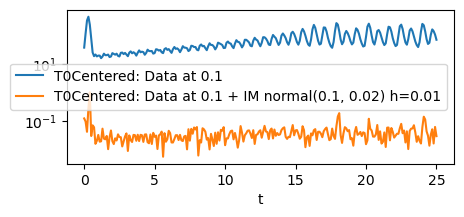

ImplicitMidpoint(interval=[0, 0.01], h=0.01, nsteps=1, f=compute_du)
ImplicitMidpoint(interval=[0, 0.01], h=0.01, nsteps=1, f=compute_du)


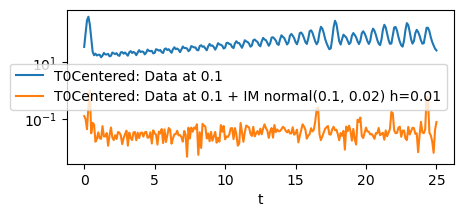

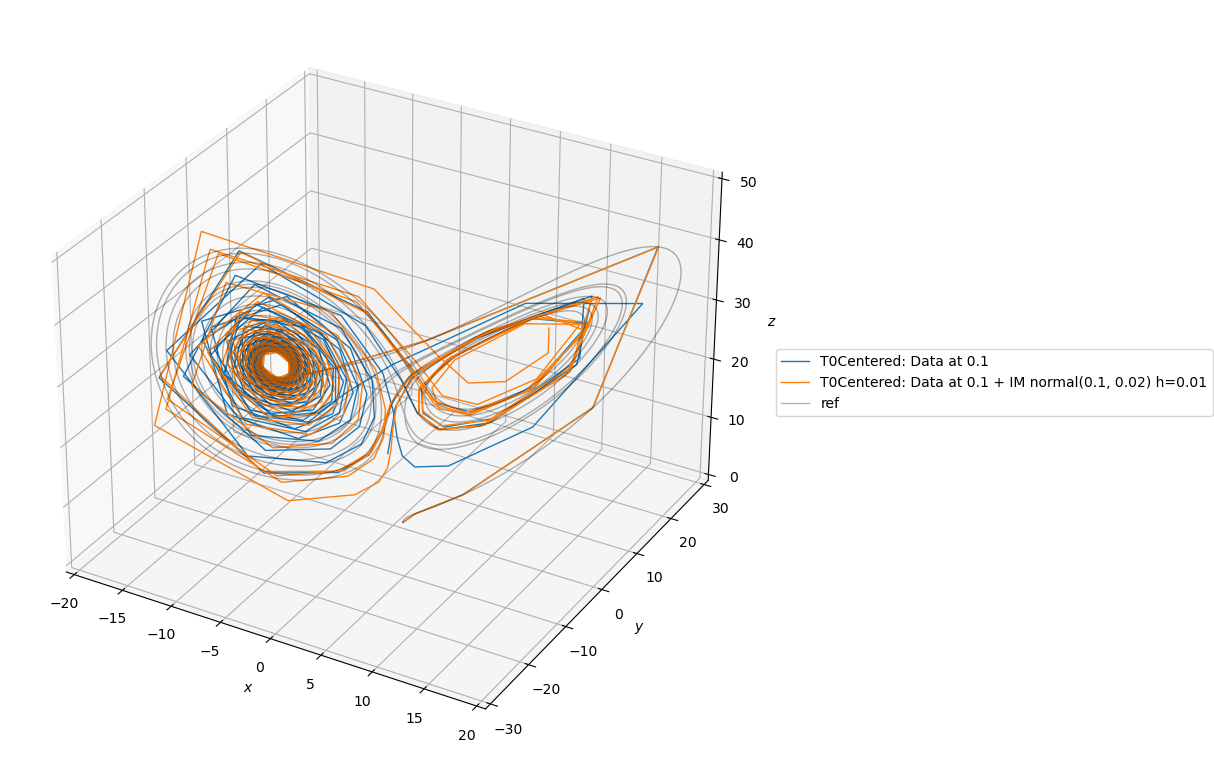

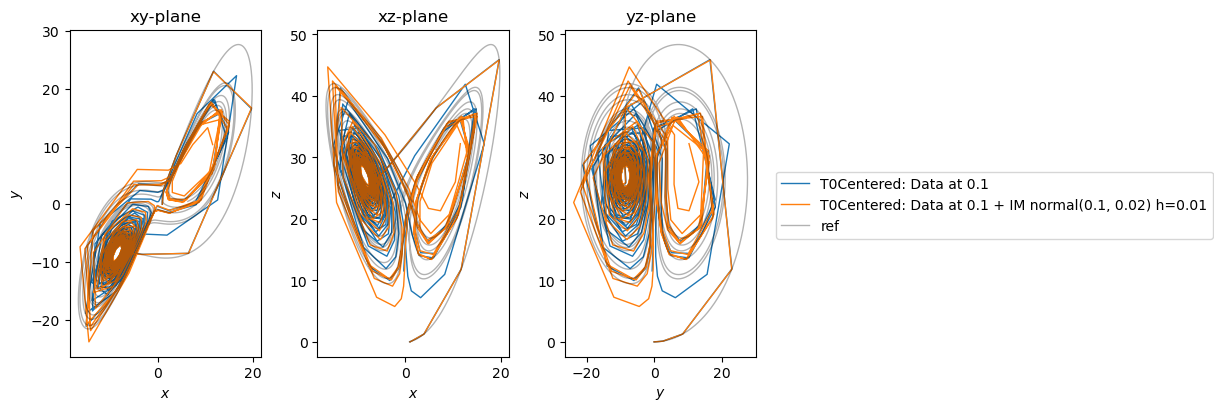

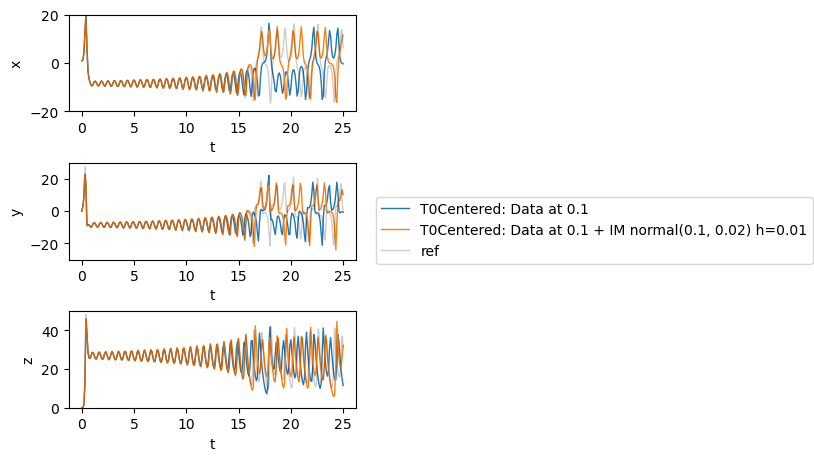

After alignment: 
	traj = LorenzTrajectory(t_range=[0.0, 25.0], dt=0.1, u0=[1. 0. 0.], states=States(problem=Lorenz(sigma=10.0, rho=28.0, beta=2.6666666666666665), shape=(251, 3)))
	ref_traj = LorenzTrajectory(t_range=[0.0, 25.0], dt=0.1, u0=[1. 0. 0.], states=States(problem=Lorenz(sigma=10.0, rho=28.0, beta=2.6666666666666665), shape=(251, 3)))
After alignment: 
	traj = LorenzTrajectory(t_range=[0.0, 25.0], dt=0.1, u0=[1. 0. 0.], states=States(problem=Lorenz(sigma=10.0, rho=28.0, beta=2.6666666666666665), shape=(251, 3)))
	ref_traj = LorenzTrajectory(t_range=[0.0, 25.0], dt=0.1, u0=[1. 0. 0.], states=States(problem=Lorenz(sigma=10.0, rho=28.0, beta=2.6666666666666665), shape=(251, 3)))


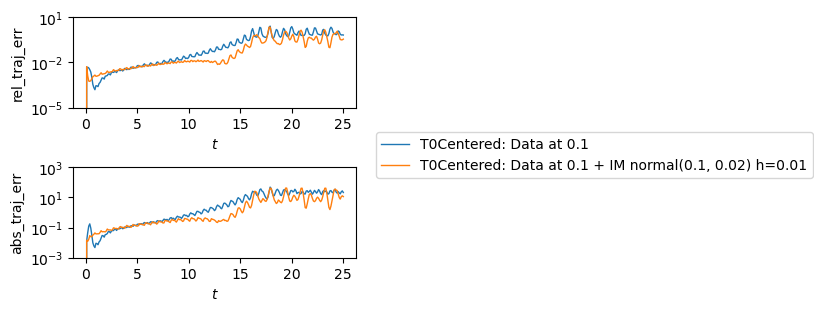

In [ ]:
dt = 0.1
T_end = 15

ref_traj = Trajectory.load_from_file(REF_TRAJ_FILEPATHS[1]["filepath"], dt=REF_TRAJ_FILEPATHS[1]["dt"])
ref_traj = ref_traj.select_between(10, T_end)

model_ckpts = {
    "T0Centered: Data at 0.1": {
        "model_name": "T0CenteredSolutionMap",
        "ckpt_dir": "/workspace/projects_rui/learnsolnmap/deep_learning/logs/train/runs/20250126-210235_fs7zlm/checkpoints",
    },
    # "T0Centered: Data at 0.1 + IM normal(0.1, 0.02) h=0.01 Box": {
    #     "model_name": "T0CenteredSolutionMap",
    #     "ckpt_dir": "/workspace/projects_rui/learnsolnmap/deep_learning/logs/train/runs/20250126-214209_qbii8s/checkpoints",
    # },  # unsup == sup data 
    "T0Centered: Data at 0.1 + IM normal(0.1, 0.02) h=0.01": {
        "model_name": "T0CenteredSolutionMap",
        "ckpt_dir": "/workspace/projects_rui/learnsolnmap/deep_learning/logs/train/runs/20250126-215330_dx37b8/checkpoints",
    },  # unsup sampled on the fly 
}

pred_trajs = []
models = []
for label, ckpt_info in model_ckpts.items():
    ckpt_path = find_latest_ckpt(ckpt_info["ckpt_dir"])
    model, _ = load_model_from_ckpt(ckpt_path, ckpt_info["model_name"])
    pred_traj = predict_sequence(model, dt, ref_traj.select_between(0, T_end))
    print(pred_traj)
    pred_trajs.append(pred_traj)
    models.append(model)


plot_numerical_residual_along_traj(models, list(model_ckpts.keys()), ref_traj.select_with_interval(dt))
plot_numerical_residual_along_traj(models, list(model_ckpts.keys()), pred_trajs)


trajs = pred_trajs + [ref_traj]
labels = list(model_ckpts.keys()) + ["ref"]

plot_xyz(trajs, legend_labels=labels, show_legend=True, axis_lims=[(-20, 20), (-30, 30), (0, 50)], figsize=(12, 10))
plot_xyz_projected(trajs, legend_labels=labels, show_legend=True)
plot_history(
    trajs, 
    func_dict={'x': lambda u: u[:, 0], 'y': lambda u: u[:, 1], 'z': lambda u: u[:, 2]}, 
    legend_labels=labels,
    xlabel='t',  
    ylims=[(-20, 20), (-30, 30), (0, 50)], 
    show_legend=True
)

plot_errors(pred_trajs, ref_traj, error_names=["rel_traj_err", "abs_traj_err"], 
            legend_labels=list(model_ckpts.keys()), show_legend=True, ylims=[(1e-5, 1e1), (1e-3, 1e3)])